# Trabalho de Visualização de Dados e Storytelling - G13

## 1. Carregar Bibliotecas e definições globais

In [46]:
%matplotlib inline
# Importar bibliotecas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'svg'

In [94]:
# Cores padronizadas
# COR_ACC = "#2148F3"
# COR_MOR = "#FF2222"

COR_ACC = plt.cm.viridis(0.8)
COR_MOR = plt.cm.viridis(0.1)

## 2. Carregar Dataset e fazer conversões

In [100]:
# Carregar dados do arquivo CSV
df = pd.read_csv("datatran2025.csv", delimiter=";", encoding="latin1")

# converter dados numericos para float
df["latitude"] = df["latitude"].str.replace(",", ".").astype(float)
df["longitude"] = df["longitude"].str.replace(",", ".").astype(float)
df["km"] = df["km"].str.replace(",", ".").astype(float)

# cria datetime a patir da data e horário
df["datetime"] = pd.to_datetime(
    df["data_inversa"] + " " + df["horario"],
    format="%Y-%m-%d %H:%M:%S"
)

# cria coluna mes
df['mes'] = df['datetime'].dt.month

# remove coluna id para esse estudo
df = df.drop(["id"], axis=1)

## 3. Limpeza dos dados

In [101]:
df.dtypes

data_inversa                         str
dia_semana                           str
horario                              str
uf                                   str
br                                 int64
km                               float64
municipio                            str
causa_acidente                       str
tipo_acidente                        str
classificacao_acidente               str
fase_dia                             str
sentido_via                          str
condicao_metereologica               str
tipo_pista                           str
tracado_via                          str
uso_solo                             str
pessoas                            int64
mortos                             int64
feridos_leves                      int64
feridos_graves                     int64
ilesos                             int64
ignorados                          int64
feridos                            int64
veiculos                           int64
latitude        

In [102]:
df.shape

(72529, 31)

In [103]:
# Verifica e remove linhas com dados faltantes

print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
display(missing_df[missing_df['Valores Faltantes'] > 0])

# Trataiva: Remoção das linhas
print(f'\nLinhas antes da limpeza: {len(df)}')
df = df.dropna(how='any')
print(f'Linhas depois da limpeza: {len(df)}')

# Verificação após tratamento
print(f'\nValores faltantes restantes: {df.isnull().sum().sum()}')

=== Valores faltantes por coluna ===


,Valores Faltantes,Percentual (%)
classificacao_acidente,1,0.00
regional,2,0.00
delegacia,22,0.03
uop,38,0.05



Linhas antes da limpeza: 72529
Linhas depois da limpeza: 72490

Valores faltantes restantes: 0


In [104]:
duplicatas = df.duplicated().sum()
print(f'=== Verificação de Dados Duplicados ===')
print(f'Total de linhas duplicadas: {duplicatas:,}')

if duplicatas > 0:
  print("\nExemplo de linhas duplicadas:")
  display(df[df.duplicated(keep=False)].head(6))
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):,}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 0

Nenhuma linha duplicata encontrada. Nenhuma ação necessária.


## 4. Análise Exploratória de Dados (EDA)

### 4.1 Acidentes e Mortes por UF

In [ ]:
# Acidentes e mortes por UF

contagem_uf = (df.groupby('uf')
                .agg(
                   quantidade=('uf', 'count'),
                   mortos=('mortos', 'sum') 
                ).reset_index()
)
contagem_uf = contagem_uf.sort_values(
    'quantidade',
    ascending=False
)

contagem_uf

=== Contagem de registros de acidentes por UF em 2025 ===


,uf,quantidade,mortos
10,MG,9569,765
23,SC,8183,434
17,PR,7628,593
18,RJ,6417,330
22,RS,4896,327
25,SP,4682,221
4,BA,4108,583
8,GO,3195,308
15,PE,3012,336
7,ES,2639,161


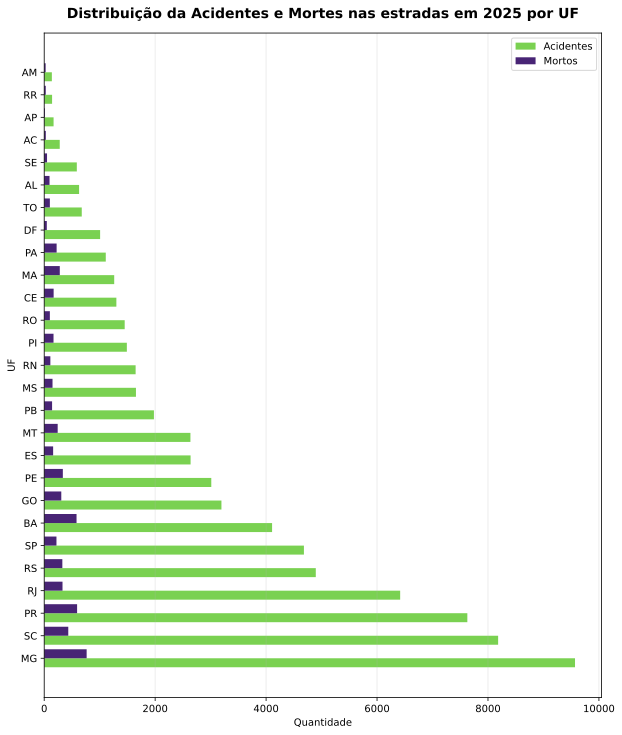

In [ ]:
# Exibe gráfico de barras
y = np.arange(len(contagem_uf))

altura = 0.4
espaco = 0.2

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_title('Distribuição da Acidentes e Mortes nas estradas em 2025 por UF', fontsize=14, fontweight='bold', pad=15)

# barras
barras1 = ax.barh(
    y - espaco,
    contagem_uf['quantidade'],
    height=altura,
    color=COR_ACC,
    label='Acidentes'
)

barras2 = ax.barh(
    y + espaco,
    contagem_uf['mortos'],
    height=altura,
    color=COR_MOR,
    label='Mortos'
)

# nomes das UFs
ax.set_yticks(y)
ax.set_yticklabels(contagem_uf['uf'])

# valores nas barras
# ax.bar_label(barras1, padding=3)
# ax.bar_label(barras2, padding=3)

ax.set_xlabel('Quantidade')
ax.set_ylabel('UF')
ax.grid(axis='x', alpha=0.3)
ax.legend()

plt.show()

### 4.2 Acidentes e Mortes por dia da semana

In [ ]:
# Acidentes e mortes por dia da semana

ordem = ['segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira', 'sexta-feira', 'sábado', 'domingo']

contagem_week_day = (df.groupby('dia_semana')
                .agg(
                   quantidade=('dia_semana', 'count'),
                   mortos=('mortos', 'sum') 
                ).reset_index()
)
contagem_week_day['dia_semana'] = pd.Categorical(
    contagem_week_day['dia_semana'], categories=ordem,
    ordered=True
)

contagem_week_day = contagem_week_day.sort_values('dia_semana')

contagem_week_day

,dia_semana,quantidade,mortos
3,segunda-feira,10277,747
6,terça-feira,9059,681
1,quarta-feira,9549,710
2,quinta-feira,9397,694
4,sexta-feira,11192,907
5,sábado,11551,1120
0,domingo,11465,1183


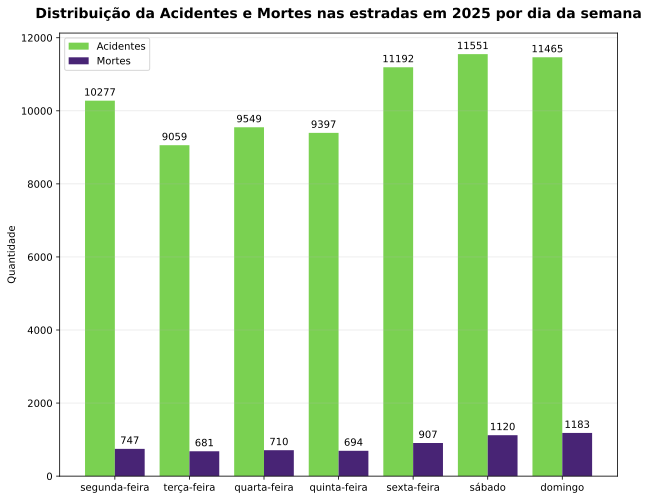

In [ ]:
# Exibe em gráfico de barras
x = np.arange(len(contagem_week_day))

largura = 0.4

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Distribuição da Acidentes e Mortes nas estradas em 2025 por dia da semana', fontsize=14, fontweight='bold', pad=15)

# barras
barras1 = ax.bar(
    x - largura/2,
    contagem_week_day['quantidade'],
    width=largura,
    color=COR_ACC,
    label='Acidentes'   
)

barras2 = ax.bar(
    x + largura/2,
    contagem_week_day['mortos'],
    width=largura,
    color=COR_MOR,
    label='Mortes'    
)

# nomes no eixo x
ax.set_xticks(x)
ax.set_xticklabels(contagem_week_day['dia_semana'])

# valores acima das barras
ax.bar_label(barras1, padding=3)
ax.bar_label(barras2, padding=3)

ax.set_ylabel('Quantidade')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.show()


### 4.3 Acidentes e Mortes por mês

In [ ]:
# Acidentes e mortes por mês

contagem_mes = (df.groupby('mes')
                .agg(
                   quantidade=('mes', 'count'),
                   mortos=('mortos', 'sum') 
                ).reset_index()
)
contagem_mes = contagem_mes.sort_values(
    'mes',
    ascending=True
)

contagem_mes

,mes,quantidade,mortos
0,1,5526,417
1,2,5284,412
2,3,5958,462
3,4,5781,495
4,5,6095,574
5,6,6120,528
6,7,6233,536
7,8,6243,554
8,9,6011,500
9,10,6249,494


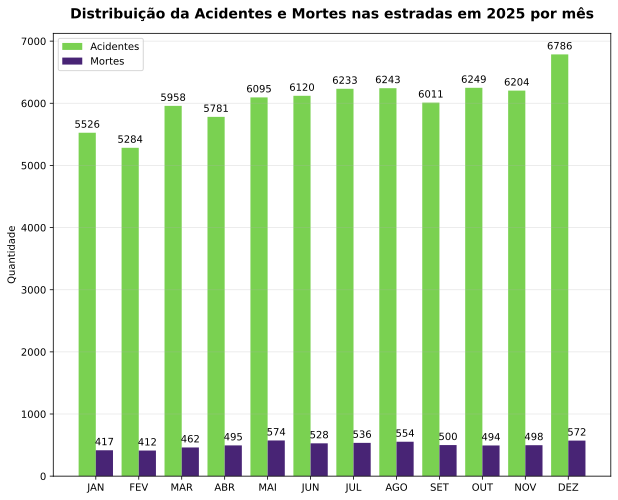

In [118]:
x = np.arange(len(contagem_mes))

largura = 0.4

rotulo_mes = ['JAN', 'FEV', 'MAR', 'ABR', 'MAI', 'JUN', 'JUL', 'AGO', 'SET', 'OUT', 'NOV', 'DEZ']

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Distribuição da Acidentes e Mortes nas estradas em 2025 por mês', fontsize=14, fontweight='bold', pad=15)

# barras
barras1 = ax.bar(
    x - largura/2,
    contagem_mes['quantidade'],
    width=largura,
    color=COR_ACC,
    label='Acidentes'   
)

barras2 = ax.bar(
    x + largura/2,
    contagem_mes['mortos'],
    width=largura,
    color=COR_MOR,
    label='Mortes'    
)

# nomes no eixo x
ax.set_xticks(x)
ax.set_xticklabels(rotulo_mes)

# valores acima das barras
ax.bar_label(barras1, padding=3)
ax.bar_label(barras2, padding=3)

ax.set_ylabel('Quantidade')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.show()